In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/Dataset.csv")

In [ ]:
df.shape

(3900, 18)

In [ ]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [ ]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [ ]:
df.isna().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


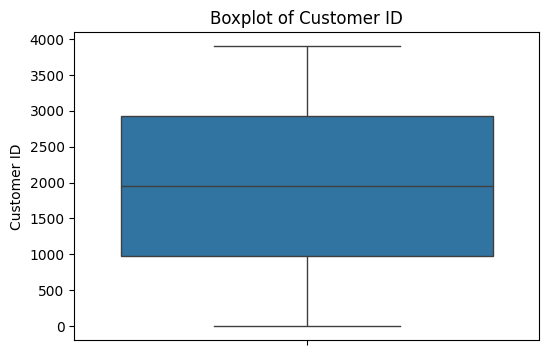

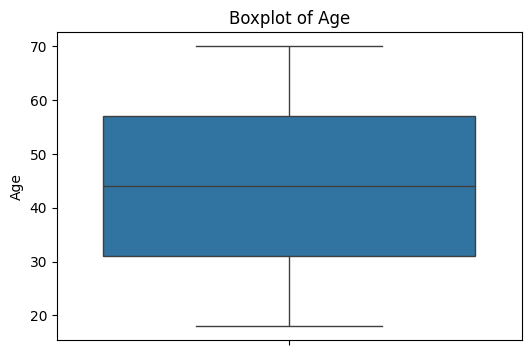

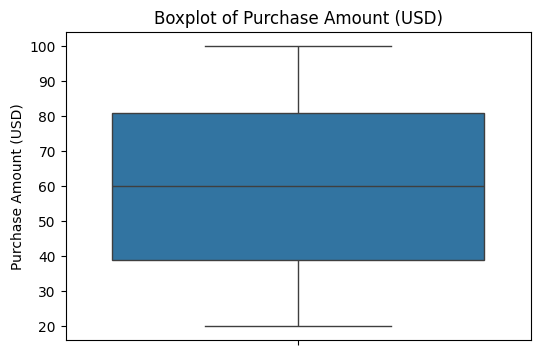

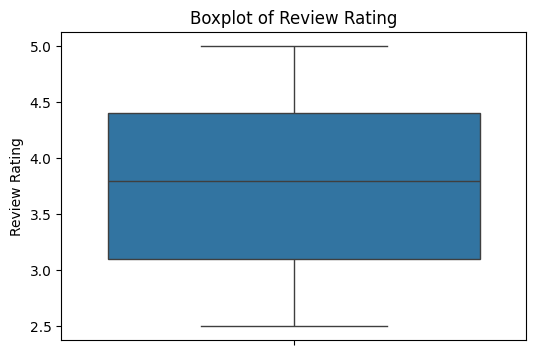

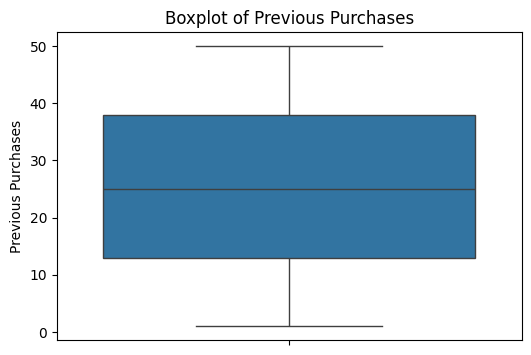

In [ ]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

In [ ]:
mean_review_rating = df["Review Rating"].mean()
df["Review Rating"] = df["Review Rating"].fillna(mean_review_rating)

In [ ]:
df['Subscription Status'].value_counts()

,count
Subscription Status,
No,2847
Yes,1053


In [ ]:
print(df['Subscription Status'].value_counts(normalize=True))

Subscription Status
No     0.73
Yes    0.27
Name: proportion, dtype: float64


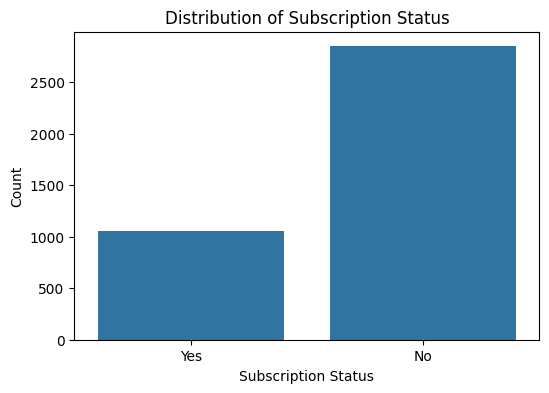

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Subscription Status")
plt.title("Distribution of Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Count")
plt.show()

In [ ]:
df['Discount Applied'].value_counts()

,count
Discount Applied,
No,2223
Yes,1677


In [ ]:
print(df['Discount Applied'].value_counts(normalize=True))

Discount Applied
No     0.57
Yes    0.43
Name: proportion, dtype: float64


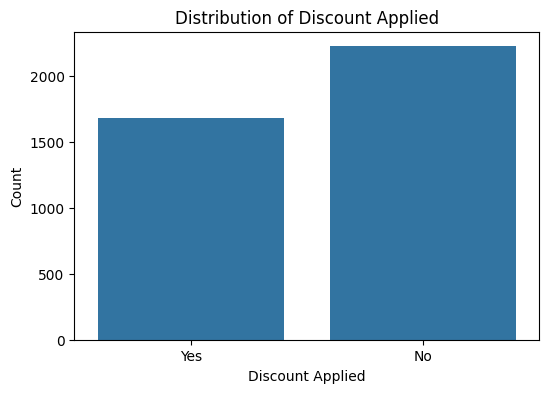

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Discount Applied")
plt.title("Distribution of Discount Applied")
plt.xlabel("Discount Applied")
plt.ylabel("Count")
plt.show()

In [ ]:
df['Promo Code Used'].value_counts()

,count
Promo Code Used,
No,2223
Yes,1677


In [ ]:
print(df['Promo Code Used'].value_counts(normalize=True))

Promo Code Used
No     0.57
Yes    0.43
Name: proportion, dtype: float64


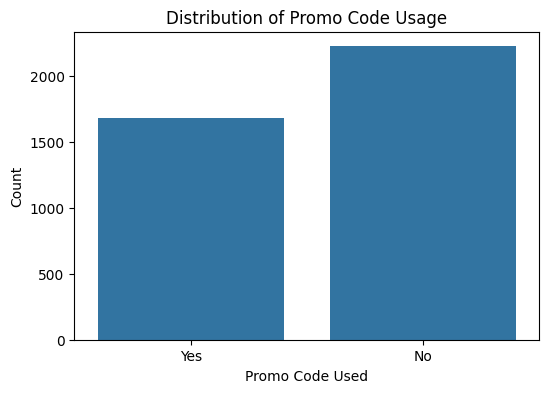

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Promo Code Used")
plt.title("Distribution of Promo Code Usage")
plt.xlabel("Promo Code Used")
plt.ylabel("Count")
plt.show()

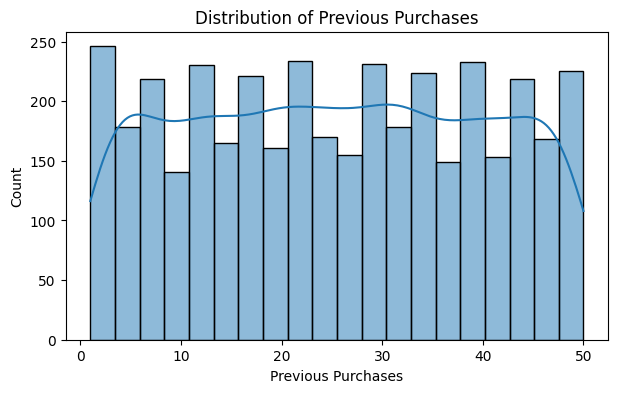

In [ ]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="Previous Purchases", kde=True, bins=20)
plt.title("Distribution of Previous Purchases")
plt.xlabel("Previous Purchases")
plt.ylabel("Count")
plt.show()

In [ ]:
df['Frequency of Purchases'].unique()

array(['Fortnightly', 'Weekly', 'Annually', 'Quarterly', 'Bi-Weekly',
       'Monthly', 'Every 3 Months'], dtype=object)

In [ ]:
df['Frequency of Purchases'].value_counts()

,count
Frequency of Purchases,
Every 3 Months,584
Annually,572
Quarterly,563
Monthly,553
Bi-Weekly,547
Fortnightly,542
Weekly,539


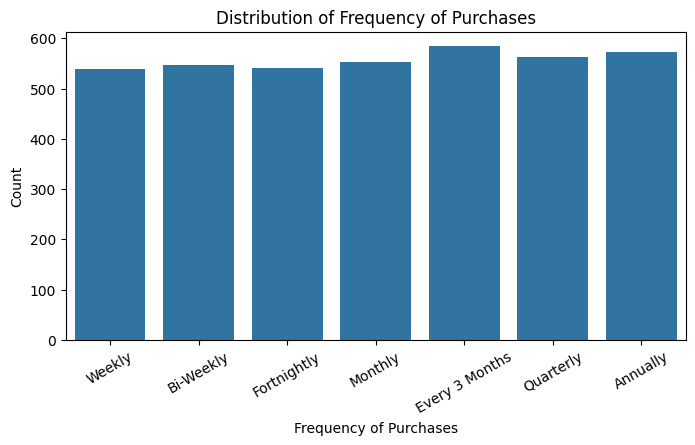

In [ ]:
frequency_order = [
    "Weekly",
    "Bi-Weekly",
    "Fortnightly",
    "Monthly",
    "Every 3 Months",
    "Quarterly",
    "Annually"
]

plt.figure(figsize=(8, 4))
sns.countplot(
    data=df,
    x="Frequency of Purchases",
    order=frequency_order
)

plt.title("Distribution of Frequency of Purchases")
plt.xlabel("Frequency of Purchases")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

In [ ]:
disc_promo = df[(df['Discount Applied'] == "Yes") & (df['Promo Code Used'] == "Yes")]
disc_promo.shape

(1677, 18)

In [ ]:
disc_promo = df[(df['Discount Applied'] == "No") & (df['Promo Code Used'] == "Yes")]
disc_promo.shape

(0, 18)

In [ ]:
disc_promo = df[(df['Discount Applied'] == "Yes") & (df['Promo Code Used'] == "No")]
disc_promo.shape

(0, 18)

In [ ]:
disc_promo = df[(df['Discount Applied'] == "No") & (df['Promo Code Used'] == "No")]
disc_promo.shape

(2223, 18)

Feature 1 : Promo Dependancy

In [ ]:
df["Discount Used Binary"] = df["Discount Applied"].map({
    "Yes": 1,
    "No": 0
})

df["Promo Dependency"] = df["Discount Used Binary"] / (df["Previous Purchases"] + 1)

df[["Discount Applied", "Previous Purchases", "Promo Dependency"]].head()

,Discount Applied,Previous Purchases,Promo Dependency
0,Yes,14,0.066667
1,Yes,2,0.333333
2,Yes,23,0.041667
3,Yes,49,0.020000
4,Yes,31,0.031250


In [ ]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Discount Used Binary,Promo Dependency
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,1,0.066667
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,1,0.333333
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,1,0.041667
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,1,0.020000
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,1,0.031250


Feature 2 - Customer Value

In [ ]:
df['Previous Purchases'].agg(['min', 'max'])

,Previous Purchases
min,1
max,50


In [ ]:
df['Purchase Amount (USD)'].agg(['min', 'max'])

,Purchase Amount (USD)
min,20
max,100


In [ ]:
frequency_map = {
    "Annually": 1,
    "Every 3 Months": 2,
    "Quarterly": 2,
    "Monthly": 3,
    "Fortnightly": 4,
    "Weekly": 5,
    "Bi-Weekly": 6
}

df["Frequency Score"] = df["Frequency of Purchases"].map(frequency_map)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

fnormalize = ["Purchase Amount (USD)","Previous Purchases","Frequency Score"]
scaler = MinMaxScaler()
df[["Purchase Amount Normalized", "Previous Purchases Normalized","Frequency Normalized"]] = scaler.fit_transform(df[fnormalize])

In [ ]:
df["Customer Value Score"] = (
    0.2 * df["Purchase Amount Normalized"] +
    0.3 * df["Previous Purchases Normalized"] +
    0.5 * df["Frequency Normalized"]
)

In [ ]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Previous Purchases,Payment Method,Frequency of Purchases,Discount Used Binary,Promo Dependency,Frequency Score,Purchase Amount Normalized,Previous Purchases Normalized,Frequency Normalized,Customer Value Score
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,14,Venmo,Fortnightly,1,0.066667,4,0.4125,0.265306,0.6,0.462092
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,2,Cash,Fortnightly,1,0.333333,4,0.5500,0.020408,0.6,0.416122
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,23,Credit Card,Weekly,1,0.041667,5,0.6625,0.448980,0.8,0.667194
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,49,PayPal,Weekly,1,0.020000,5,0.8750,0.979592,0.8,0.868878
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,31,PayPal,Annually,1,0.031250,1,0.3625,0.612245,0.0,0.256173


**Feature: Customer Value Score**

**Calculated as:** 0.2 × norm(Purchase Amount) + 0.3 × norm(Previous Purchases) + 0.5 × norm(Frequency of Purchases) where each variable is normalized to [0,1] using min-max scaling before weighting.

**Weights reflect:** Purchase amount is weighted lowest because a single high-spend transaction does not indicate long-term value. Previous purchases and frequency are weighted higher because they capture sustained engagement — a customer who buys repeatedly and regularly contributes more predictably to revenue than one who spends big once.

**Captures:** The overall commercial value of a customer to the brand, combining how much they spend, how often they buy, and how consistently they return.

**Range:** 0 to 1 — closer to 0 indicates a low-value customer (low spend, few purchases, infrequent); closer to 1 indicates a high-value customer (higher spend, long purchase history, frequent buyer).

Feature 3 - Satisfaction Score

In [ ]:
df['Review Rating'].agg(['min', 'max'])

,Review Rating
min,2.5
max,5.0


In [ ]:
df["Satisfaction Score"] = df["Review Rating"] / 5

df[["Review Rating", "Satisfaction Score"]].head()

,Review Rating,Satisfaction Score
0,3.1,0.62
1,3.1,0.62
2,3.1,0.62
3,3.5,0.70
4,2.7,0.54


**Feature: Satisfaction Score**

**Calculated as:** Review Rating / 5 — normalizing against the true scale maximum to preserve the absolute meaning of the rating, rather than the observed minimum which would artificially inflate scores.
Captures: How satisfied a customer is with their purchase, as directly expressed through their review rating.

**Range:** 0 to 1 — closer to 0 indicates dissatisfaction, closer to 1 indicates a highly satisfied customer. Note that in practice, observed scores cluster between 0.5 and 1.0 (ratings 2.5–5.0), meaning the lower half of the scale represents the least satisfied customers in this dataset.

Feature 4 - Loyalty

In [ ]:
df["Subscription Status Binary"] = df["Subscription Status"].map({
    "Yes": 1,
    "No": 0
})

In [ ]:
# Definition 1: Behavioral Loyalty Score
df["Behavioral Loyalty Score"] = df["Customer Value Score"] * (1 - df["Promo Dependency"])

# Definition 2: Attitudinal Loyalty Score
df["Attitudinal Loyalty Score"] = df["Satisfaction Score"] + (0.1 * df["Subscription Status Binary"])

# Primary Loyalty Score
df["Loyalty Score"] = df["Behavioral Loyalty Score"]

In [ ]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Frequency Score,Purchase Amount Normalized,Previous Purchases Normalized,Frequency Normalized,Customer Value Score,Satisfaction Score,Subscription Status Binary,Behavioral Loyalty Score,Attitudinal Loyalty Score,Loyalty Score
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,4,0.4125,0.265306,0.6,0.462092,0.62,1,0.431286,0.72,0.431286
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,4,0.5500,0.020408,0.6,0.416122,0.62,1,0.277415,0.72,0.277415
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,5,0.6625,0.448980,0.8,0.667194,0.62,1,0.639394,0.72,0.639394
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,5,0.8750,0.979592,0.8,0.868878,0.70,1,0.851500,0.80,0.851500
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,1,0.3625,0.612245,0.0,0.256173,0.54,1,0.248168,0.64,0.248168


**Feature: Loyalty Score**

**Definition 1 (Behavioral):** Customer Value Score × (1 - Promo Dependency Score)
High frequency, high spend customers who buy without needing discounts score highest.

**Definition 2 (Attitudinal):** Satisfaction Score + 0.1 × Subscription Status (1/0)
Captures how a customer feels about the brand, with subscription as a small positive signal of active commitment.

**Argument for Definition 1:** Chosen as the primary loyalty metric because it is revenue-grounded and directly actionable — the brand can identify which customers drive consistent revenue independently of promotional spend, and target retention efforts accordingly. Definition 2 is retained as a complementary signal to flag customers who are behaviorally loyal but potentially dissatisfied — a hidden retention risk that purchase behavior alone cannot reveal.

**Range:** 0 to 1 — closer to 0 indicates a disloyal or promo-dependent customer, closer to 1 indicates a genuinely loyal, high-value customer who buys independently of discounts.

Feature 5 - Value Tier

In [ ]:
def value_tier(score):
      if score <= 0.5:
        return "Low"
      elif score <= 0.79:
        return "Medium"
      else:
        return "High"

df["Value Tier"] = df["Customer Value Score"].apply(value_tier)

df[["Customer Value Score", "Value Tier"]].head()

,Customer Value Score,Value Tier
0,0.462092,Low
1,0.416122,Low
2,0.667194,Medium
3,0.868878,High
4,0.256173,Low


Feature 6 - Satisfaction Flag

In [ ]:
def satisfaction_flag(rating):
    if rating >= 4.0:
        return 1
    else:
        return 0

df["Satisfaction Flag"] = df["Review Rating"].apply(satisfaction_flag)

df[["Review Rating", "Satisfaction Flag"]].head()

,Review Rating,Satisfaction Flag
0,3.1,0
1,3.1,0
2,3.1,0
3,3.5,0
4,2.7,0


In [ ]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Previous Purchases Normalized,Frequency Normalized,Customer Value Score,Satisfaction Score,Subscription Status Binary,Behavioral Loyalty Score,Attitudinal Loyalty Score,Loyalty Score,Value Tier,Satisfaction Flag
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,0.265306,0.6,0.462092,0.62,1,0.431286,0.72,0.431286,Low,0
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,0.020408,0.6,0.416122,0.62,1,0.277415,0.72,0.277415,Low,0
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,0.448980,0.8,0.667194,0.62,1,0.639394,0.72,0.639394,Medium,0
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,0.979592,0.8,0.868878,0.70,1,0.851500,0.80,0.851500,High,0
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,0.612245,0.0,0.256173,0.54,1,0.248168,0.64,0.248168,Low,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer ID                    3900 non-null   int64  
 1   Age                            3900 non-null   int64  
 2   Gender                         3900 non-null   object 
 3   Item Purchased                 3900 non-null   object 
 4   Category                       3900 non-null   object 
 5   Purchase Amount (USD)          3900 non-null   int64  
 6   Location                       3900 non-null   object 
 7   Size                           3900 non-null   object 
 8   Color                          3900 non-null   object 
 9   Season                         3900 non-null   object 
 10  Review Rating                  3900 non-null   float64
 11  Subscription Status            3900 non-null   object 
 12  Shipping Type                  3900 non-null   o

In [ ]:
#from google.colab import files
#df.to_csv("engineered_dataset.csv", index=False)
#files.download("engineered_dataset.csv")

In [ ]:
df['Promo Dependency'].agg(['min', 'max'])

,Promo Dependency
min,0.0
max,0.5


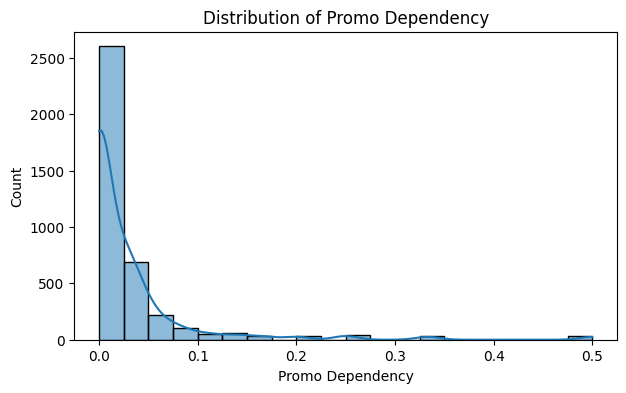

In [ ]:
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="Promo Dependency", kde=True, bins=20)
plt.title("Distribution of Promo Dependency")
plt.xlabel("Promo Dependency")
plt.ylabel("Count")
plt.show()

In [ ]:
df['Promo Dependency'].mean()

np.float64(0.029907820168096916)